In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
train = pd.read_csv('clean_data/clean_data_train.csv')
train.head()

,time,wind_speed_10m,temperature_2m,cloud_cover,relative_humidity_2m,surface_pressure,precipitation,vapour_pressure_deficit
0,2021-01-01 00:00:00,26.144030,19.50,100.0,70.98951,1020.28920,0.0,0.657872
1,2021-01-01 01:00:00,24.192429,19.50,100.0,68.94631,1019.78986,0.0,0.704225
2,2021-01-01 02:00:00,23.565569,19.35,99.0,67.36236,1019.09000,0.0,0.733305
3,2021-01-01 03:00:00,24.192429,19.20,91.0,68.21654,1018.59010,0.0,0.707482
4,2021-01-01 04:00:00,23.838959,19.25,100.0,66.90323,1018.89010,0.0,0.739021


In [4]:
# Load data
train_df = pd.read_csv('clean_data/clean_data_train.csv')
test_df = pd.read_csv('clean_data/clean_data_test.csv')

# Parse datetime
train_df['time'] = pd.to_datetime(train_df['time'])
test_df['time'] = pd.to_datetime(test_df['time'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain time range:", train_df['time'].min(), "→", train_df['time'].max())
print("Test time range:", test_df['time'].min(), "→", test_df['time'].max())
print("\nColumns:", train_df.columns.tolist())

Train shape: (42573, 8)
Test shape: (4731, 8)

Train time range: 2021-01-01 00:00:00 → 2025-11-09 20:00:00
Test time range: 2025-11-09 21:00:00 → 2026-05-25 23:00:00

Columns: ['time', 'wind_speed_10m', 'temperature_2m', 'cloud_cover', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'vapour_pressure_deficit']


In [5]:
train_df.describe().round(2)

,time,wind_speed_10m,temperature_2m,cloud_cover,relative_humidity_2m,surface_pressure,precipitation,vapour_pressure_deficit
count,42573,42573.00,42573.00,42573.00,42573.00,42573.00,42573.00,42573.00
mean,2023-06-06 22:00:00,10.32,26.33,74.69,81.87,1009.03,0.28,0.70
min,2021-01-01 00:00:00,0.00,15.10,0.00,30.71,982.17,0.00,0.00
25%,2022-03-20 11:00:00,5.34,23.80,49.00,75.95,1004.86,0.00,0.29
50%,2023-06-06 22:00:00,9.00,26.20,97.00,84.47,1008.64,0.00,0.50
75%,2024-08-23 09:00:00,13.98,28.65,100.00,90.59,1013.11,0.10,0.87
max,2025-11-09 20:00:00,59.18,40.15,100.00,100.00,1025.09,41.90,5.15
std,NaN,6.52,3.78,34.04,11.70,5.38,1.10,0.64


# 1. EDA

## 1.1 Kiểm tra null, ouliers

=== MISSING VALUES ===
time                       0
wind_speed_10m             0
temperature_2m             0
cloud_cover                0
relative_humidity_2m       0
surface_pressure           0
precipitation              0
vapour_pressure_deficit    0
dtype: int64

=== SỐ LƯỢNG OUTLIERS THEO IQR ===
wind_speed_10m: 872 outliers (2.05%)
temperature_2m: 424 outliers (1.00%)
cloud_cover: 0 outliers (0.00%)
relative_humidity_2m: 1409 outliers (3.31%)
surface_pressure: 16 outliers (0.04%)
precipitation: 7378 outliers (17.33%)
vapour_pressure_deficit: 3244 outliers (7.62%)


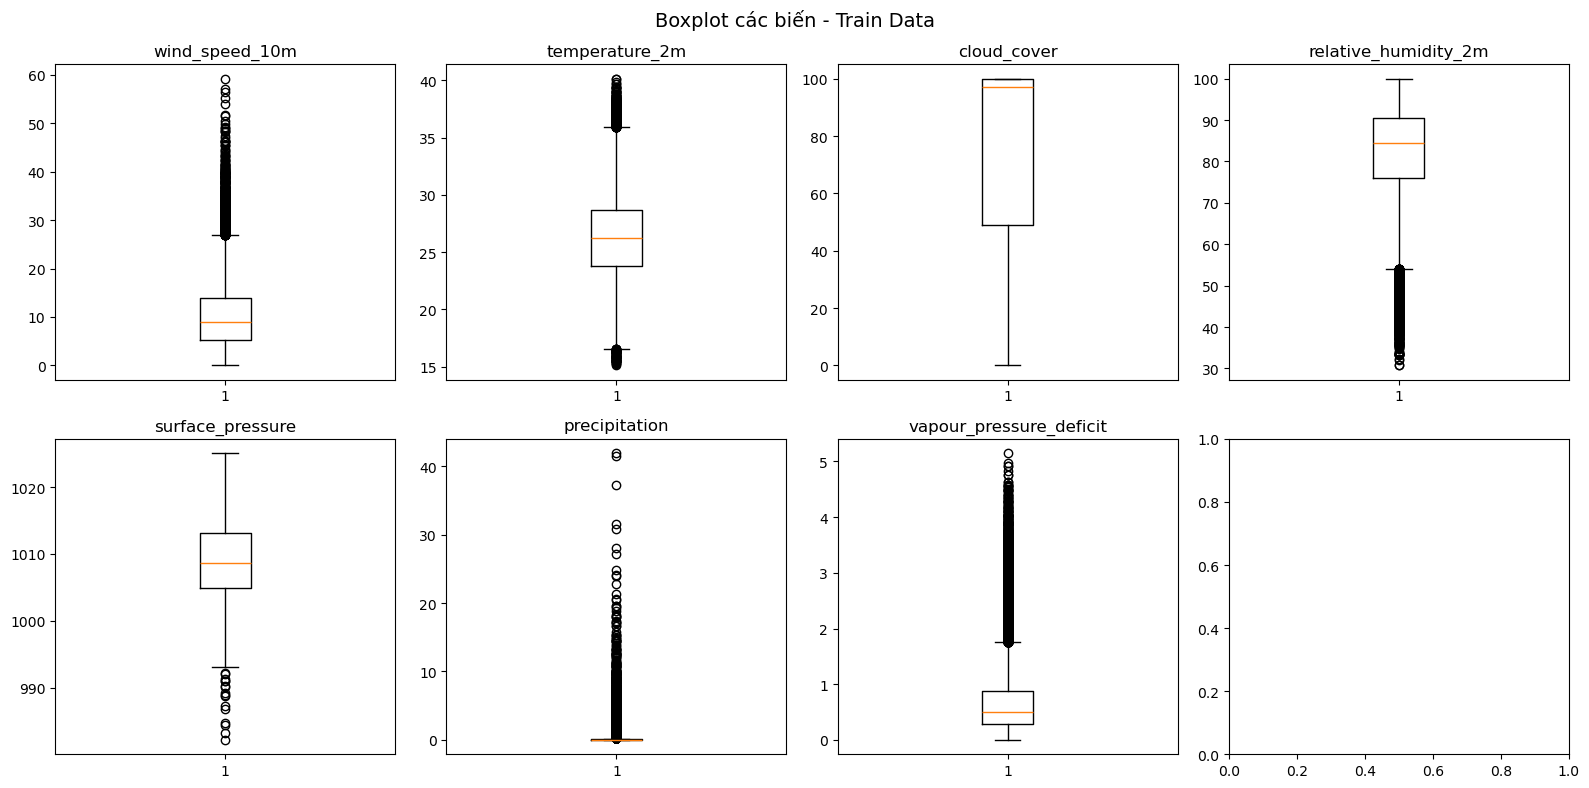

In [6]:
# Kiểm tra missing values
print("=== MISSING VALUES ===")
print(train_df.isnull().sum())

# Kiểm tra outliers theo IQR
print("\n=== SỐ LƯỢNG OUTLIERS THEO IQR ===")
numeric_cols = [col for col in train_df.columns if col != 'time']
for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    pct = len(outliers) / len(train_df) * 100
    print(f"{col}: {len(outliers)} outliers ({pct:.2f}%)")

# Boxplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(train_df[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Boxplot các biến - Train Data', fontsize=14)
plt.tight_layout()
plt.show()

Nhờ việc thiết lập tần suất (asfreq) ở bước làm sạch, việc kiểm tra khuyết thiếu bằng isna() cho thấy dữ liệu hoàn toàn liên tục

## Kiểm tra trend, tính mùa vụ, chu kỳ

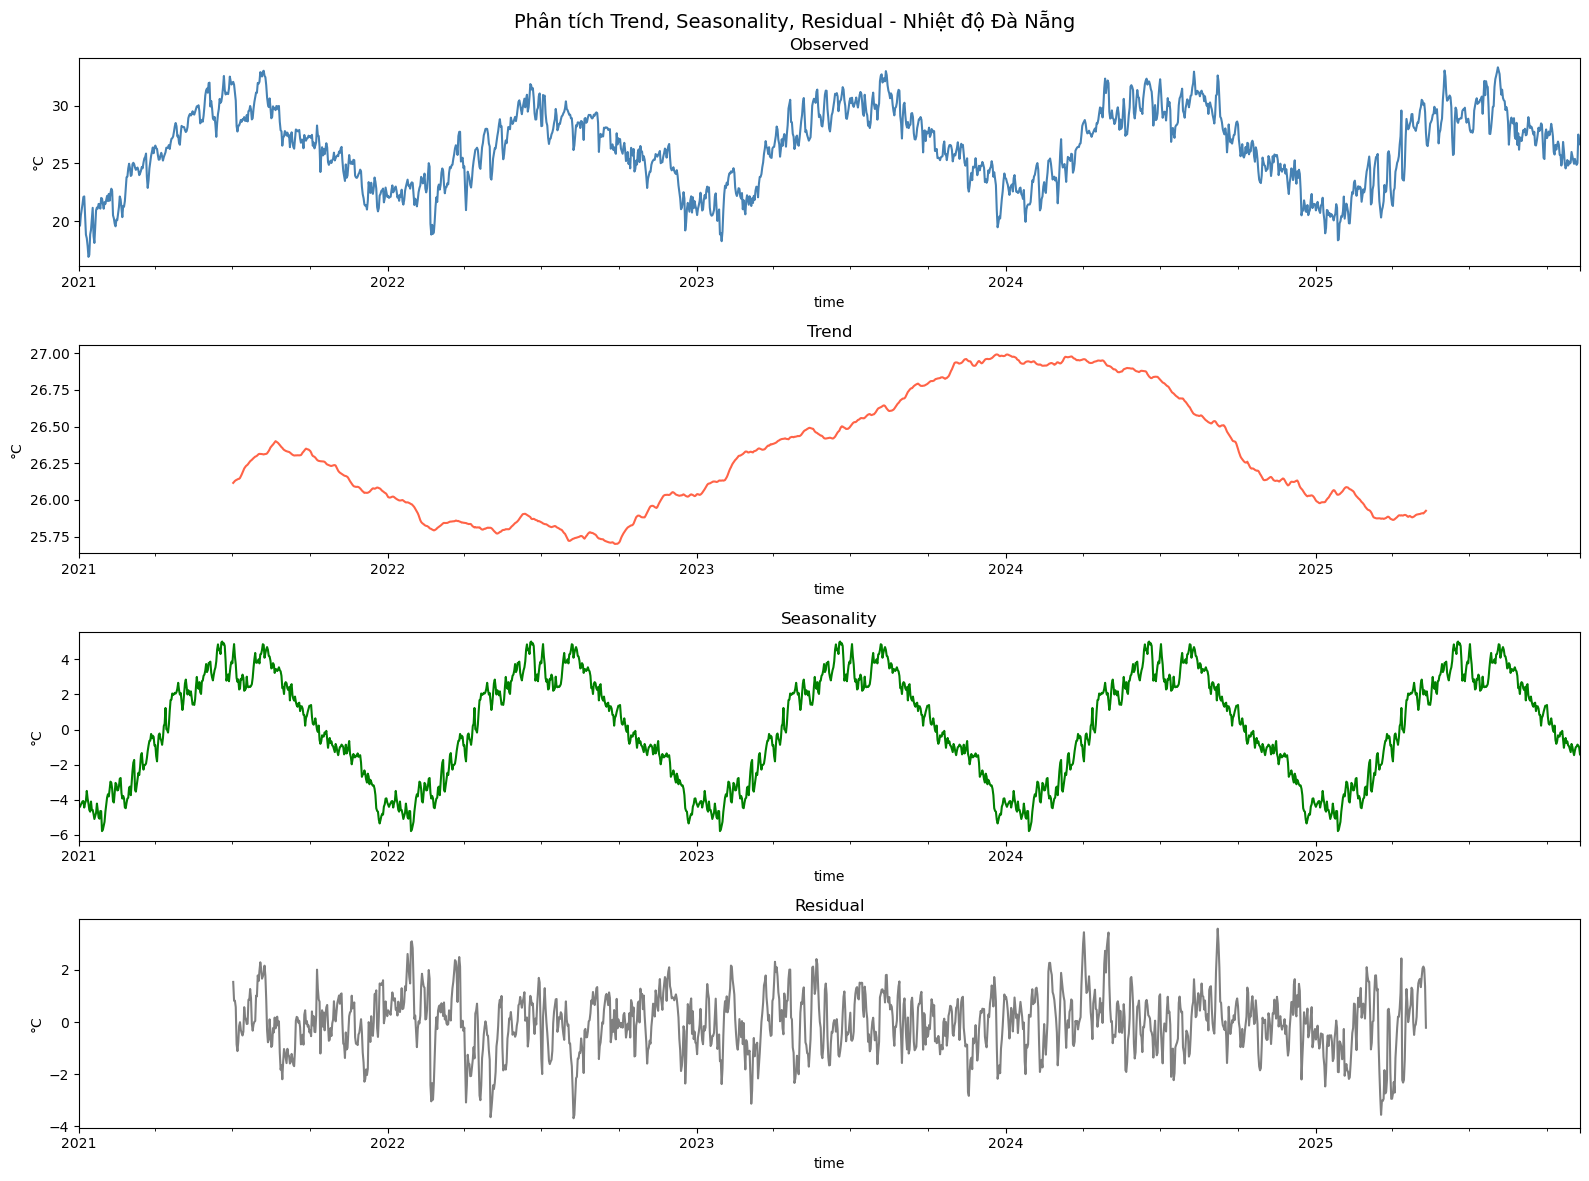

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Dùng dữ liệu daily trung bình để decompose cho rõ hơn
daily = train_df.set_index('time')['temperature_2m'].resample('D').mean()

# Decompose với period=365 (chu kỳ năm)
decompose_result = seasonal_decompose(daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

decompose_result.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('°C')

decompose_result.trend.plot(ax=axes[1], color='tomato')
axes[1].set_title('Trend')
axes[1].set_ylabel('°C')

decompose_result.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality')
axes[2].set_ylabel('°C')

decompose_result.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residual')
axes[3].set_ylabel('°C')

plt.suptitle('Phân tích Trend, Seasonality, Residual - Nhiệt độ Đà Nẵng', 
             fontsize=14)
plt.tight_layout()
plt.show()

## Kiểm tra phân phối của dữ liệu

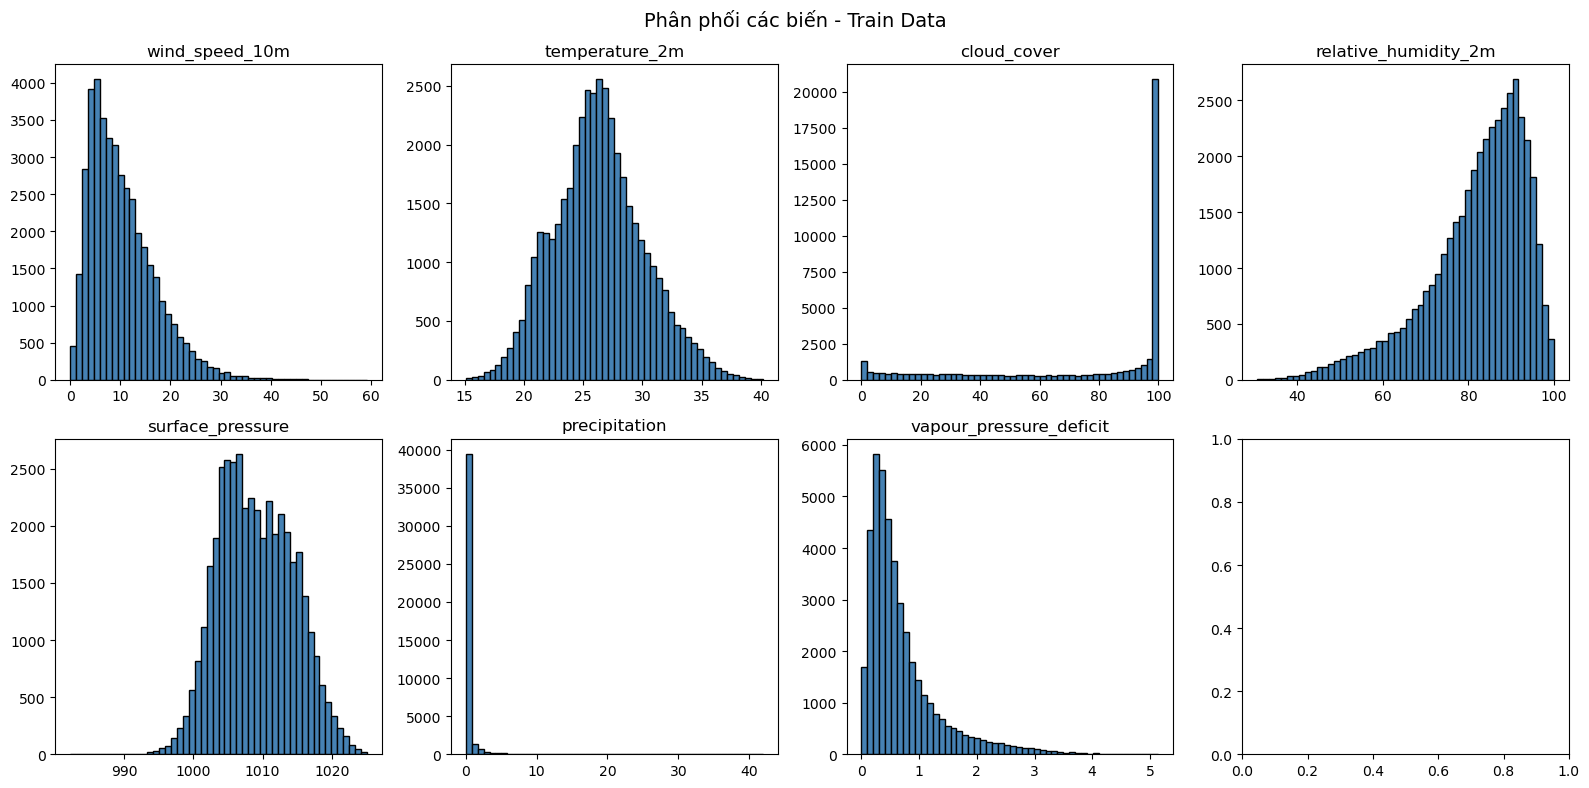

=== SKEWNESS VÀ KURTOSIS ===
Biến                             Skewness   Kurtosis
----------------------------------------------------
wind_speed_10m                      1.179      2.000
temperature_2m                      0.241     -0.041
cloud_cover                        -1.020     -0.530
relative_humidity_2m               -1.105      1.048
surface_pressure                    0.150     -0.501
precipitation                      12.142    257.591
vapour_pressure_deficit             2.095      5.285


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_cols = [col for col in train_df.columns if col != 'time']

for i, col in enumerate(numeric_cols):
    axes[i].hist(train_df[col], bins=50, 
                 edgecolor='black', color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Phân phối các biến - Train Data', fontsize=14)
plt.tight_layout()
plt.show()

# Skewness và Kurtosis
print("=== SKEWNESS VÀ KURTOSIS ===")
print(f"{'Biến':<30} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 52)
for col in numeric_cols:
    skew = train_df[col].skew()
    kurt = train_df[col].kurt()
    print(f"{col:<30} {skew:>10.3f} {kurt:>10.3f}")

## Kiểm tra tính dừng của dữ liệu

In [9]:
from statsmodels.tsa.stattools import adfuller

print("=== KIỂM ĐỊNH TÍNH DỪNG (ADF TEST) ===")
print(f"{'Biến':<30} {'ADF Stat':>12} {'p-value':>10} {'Kết luận':>15}")
print("-" * 70)

numeric_cols = [col for col in train_df.columns if col != 'time']

for col in numeric_cols:
    result = adfuller(train_df[col].dropna(), autolag='AIC')
    adf_stat = result[0]
    p_value = result[1]
    conclusion = "Dừng" if p_value < 0.05 else "Không dừng"
    print(f"{col:<30} {adf_stat:>12.4f} {p_value:>10.4f} {conclusion:>15}")

=== KIỂM ĐỊNH TÍNH DỪNG (ADF TEST) ===
Biến                               ADF Stat    p-value        Kết luận
----------------------------------------------------------------------
wind_speed_10m                     -18.3741     0.0000            Dừng
temperature_2m                      -5.7968     0.0000            Dừng
cloud_cover                        -16.8754     0.0000            Dừng
relative_humidity_2m               -11.1400     0.0000            Dừng
surface_pressure                    -7.9186     0.0000            Dừng
precipitation                      -20.4886     0.0000            Dừng
vapour_pressure_deficit             -8.8953     0.0000            Dừng


## Kiểm tra tính tự tương quan (ACF/ PACF)

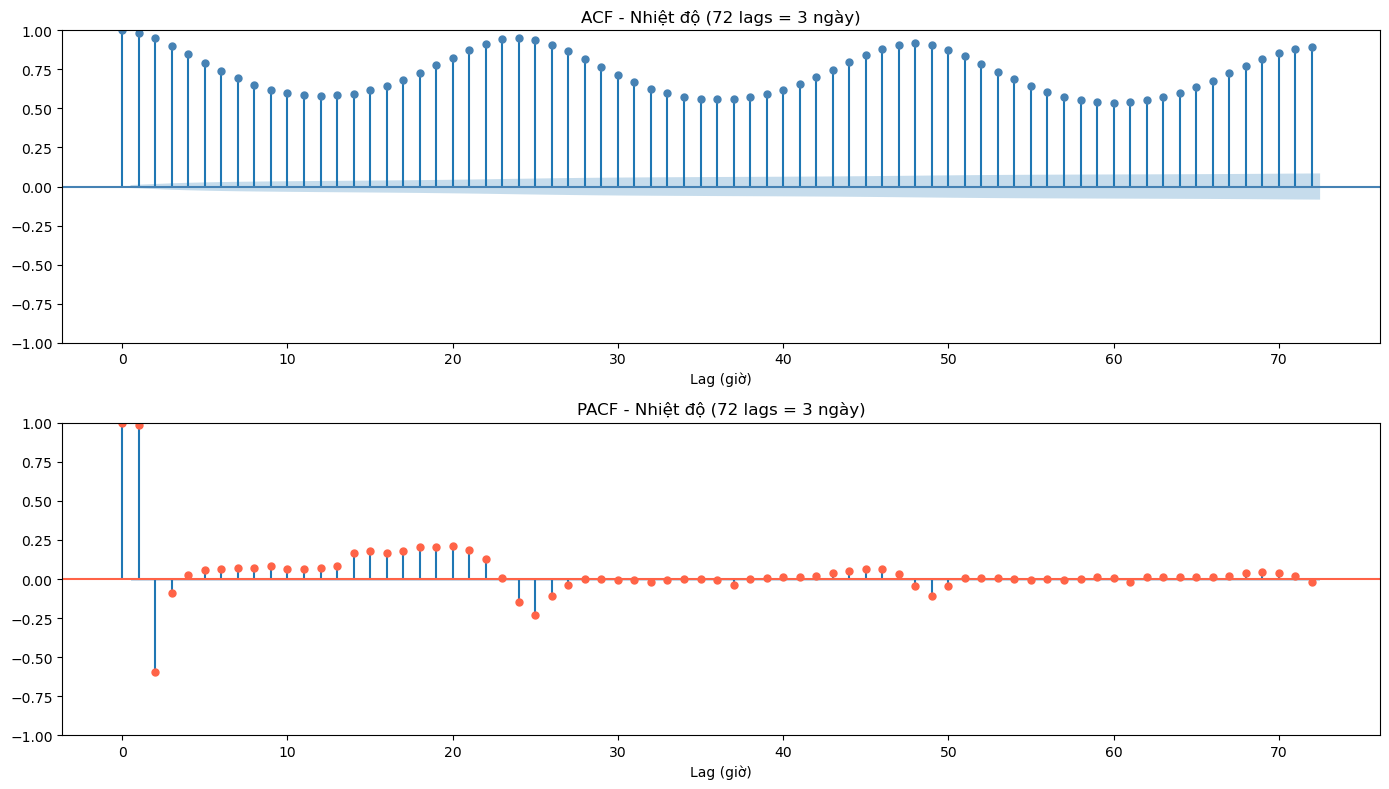

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Dùng 72 lags = 3 ngày
plot_acf(train_df['temperature_2m'], lags=72, ax=axes[0], color='steelblue')
axes[0].set_title('ACF - Nhiệt độ (72 lags = 3 ngày)')
axes[0].set_xlabel('Lag (giờ)')

plot_pacf(train_df['temperature_2m'], lags=72, ax=axes[1], color='tomato')
axes[1].set_title('PACF - Nhiệt độ (72 lags = 3 ngày)')
axes[1].set_xlabel('Lag (giờ)')

plt.tight_layout()
plt.show()

## Kiểm tra biến ngoại sinh

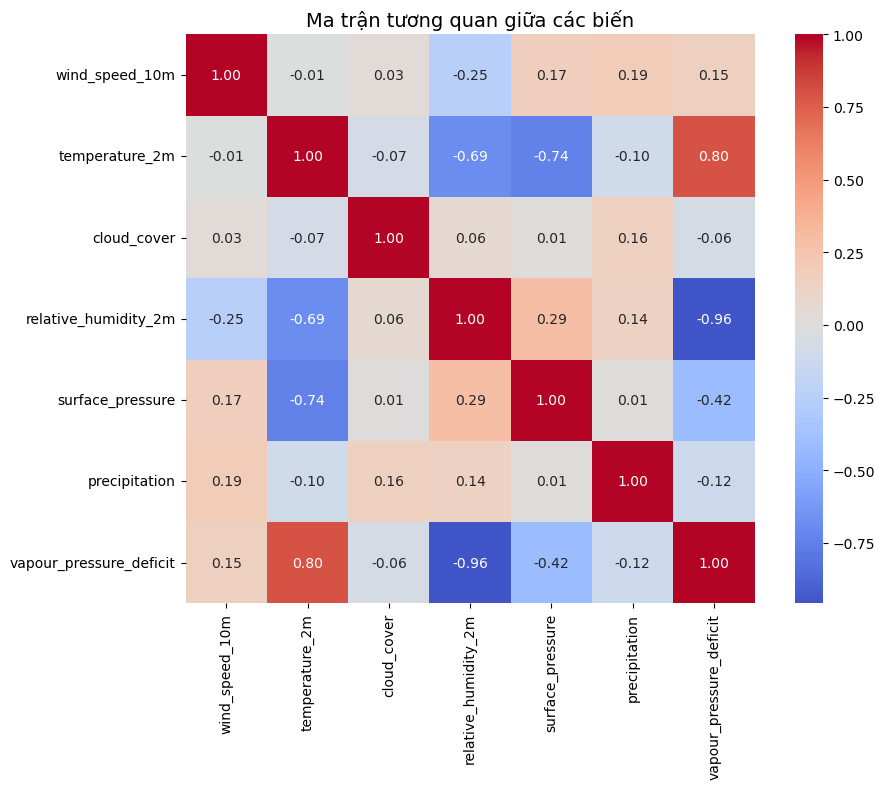


=== TƯƠNG QUAN VỚI temperature_2m ===
temperature_2m             1.000
vapour_pressure_deficit    0.796
wind_speed_10m            -0.009
cloud_cover               -0.070
precipitation             -0.095
relative_humidity_2m      -0.690
surface_pressure          -0.737
Name: temperature_2m, dtype: float64


In [11]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

cols = [col for col in train_df.columns if col != 'time']
corr_matrix = train_df[cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Ma trận tương quan giữa các biến', fontsize=14)
plt.tight_layout()
plt.show()

# In tương quan với temperature_2m
print("\n=== TƯƠNG QUAN VỚI temperature_2m ===")
print(corr_matrix['temperature_2m'].sort_values(ascending=False).round(3))

### Kết luận phần Kiểm tra biến ngoại sinh

Dựa vào ma trận tương quan:
- `apparent_temperature` có tương quan **0.96** với `temperature_2m` 
  → gần như trùng lặp thông tin, gây **data leakage** → **loại bỏ**
- `vapour_pressure_deficit` (0.80) và `surface_pressure` (-0.74), 
  `relative_humidity_2m` (-0.69) → tương quan cao → **giữ lại làm biến ngoại sinh**
- `wind_speed_10m` (-0.01), `cloud_cover` (-0.07), `precipitation` (-0.10) 
  → tương quan thấp với nhiệt độ nhưng vẫn **giữ lại** vì có ý nghĩa khí tượng

In [12]:
# Bỏ apparent_temperature dựa trên kết quả EDA
# Lý do: tương quan 0.96 với temperature_2m → data leakage
train_df = train_df.drop(columns=['apparent_temperature'], errors='ignore')
test_df = test_df.drop(columns=['apparent_temperature'], errors='ignore')

print("Sau khi bỏ apparent_temperature:")
print("Train columns:", train_df.columns.tolist())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Sau khi bỏ apparent_temperature:
Train columns: ['time', 'wind_speed_10m', 'temperature_2m', 'cloud_cover', 'relative_humidity_2m', 'surface_pressure', 'precipitation', 'vapour_pressure_deficit']
Train shape: (42573, 8)
Test shape: (4731, 8)


# 2. Feature Engineering

## Phân tích thành phần chính (PCA)

### Chuẩn hóa dữ liệu (StandardScaler)

In [13]:
from sklearn.preprocessing import StandardScaler

# Các biến ngoại sinh (không bao gồm target và time)
feature_cols = ['wind_speed_10m', 'cloud_cover', 'relative_humidity_2m',
                'surface_pressure', 'precipitation', 'vapour_pressure_deficit']

# Tách features
X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values

# Chuẩn hóa - chỉ fit trên train, transform cả train lẫn test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kiểm tra kết quả
print("=== KẾT QUẢ CHUẨN HÓA ===")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"\nTrước chuẩn hóa (train):")
print(f"  Mean: {X_train.mean(axis=0).round(3)}")
print(f"  Std:  {X_train.std(axis=0).round(3)}")
print(f"\nSau chuẩn hóa (train):")
print(f"  Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"  Std:  {X_train_scaled.std(axis=0).round(4)}")

=== KẾT QUẢ CHUẨN HÓA ===

X_train_scaled shape: (42573, 6)
X_test_scaled shape: (4731, 6)

Trước chuẩn hóa (train):
  Mean: [1.032300e+01 7.468700e+01 8.187400e+01 1.009028e+03 2.760000e-01
 7.040000e-01]
  Std:  [ 6.518 34.041 11.703  5.383  1.097  0.642]

Sau chuẩn hóa (train):
  Mean: [-0. -0. -0. -0.  0.  0.]
  Std:  [1. 1. 1. 1. 1. 1.]


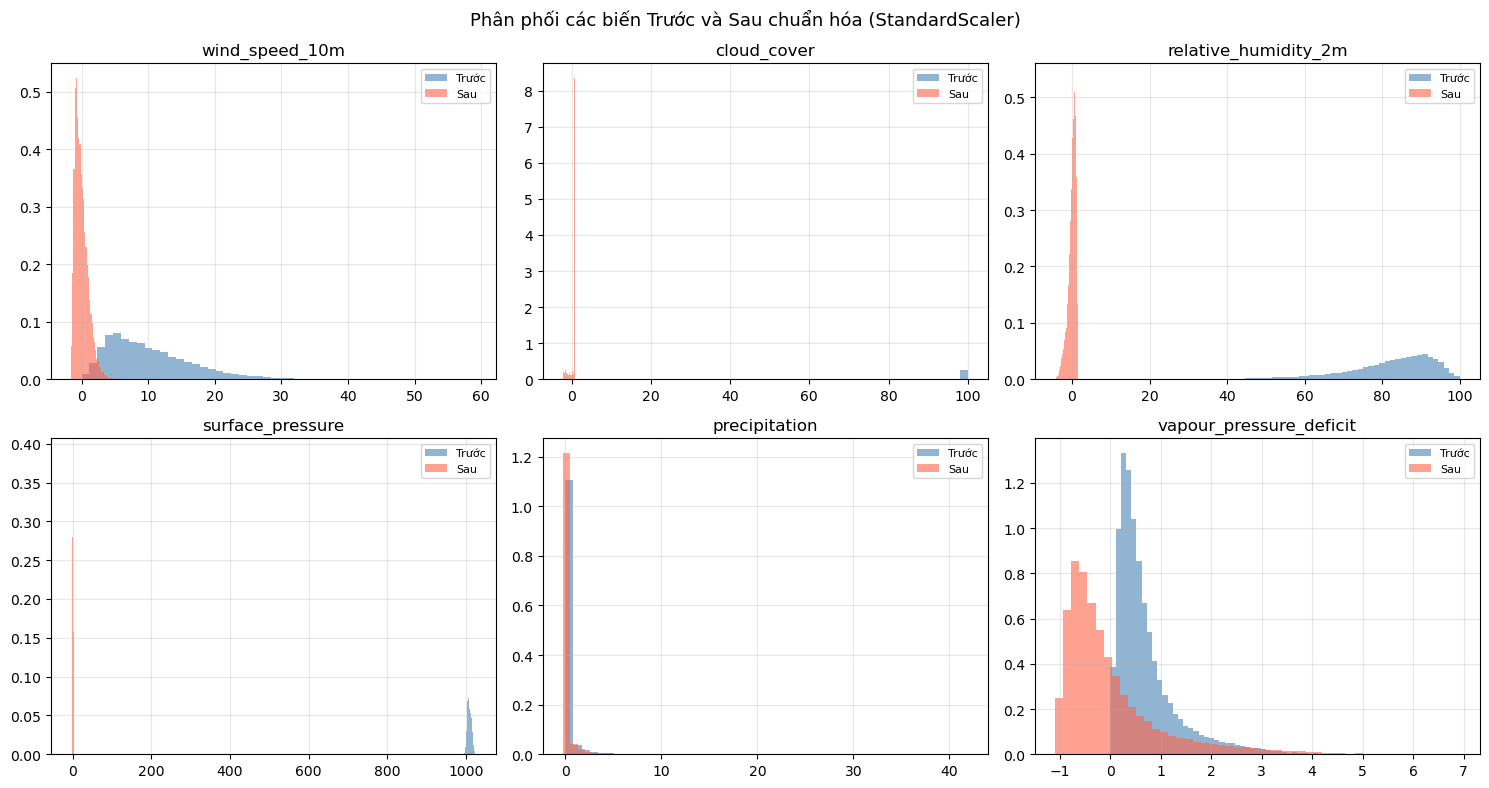

In [14]:
# So sánh phân phối TRƯỚC và SAU chuẩn hóa
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(feature_cols):
    ax = axes[i//3][i%3]
    ax.hist(X_train[:, i], bins=50, alpha=0.6, 
            color='steelblue', label='Trước', density=True)
    ax.hist(X_train_scaled[:, i], bins=50, alpha=0.6, 
            color='tomato', label='Sau', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Phân phối các biến Trước và Sau chuẩn hóa (StandardScaler)', 
             fontsize=13)
plt.tight_layout()
plt.show()

### Tính ma trận hiệp phương sai

=== MA TRẬN HIỆP PHƯƠNG SAI ===
                         wind_speed_10m  cloud_cover  relative_humidity_2m  \
wind_speed_10m                    1.000        0.032                -0.248   
cloud_cover                       0.032        1.000                 0.060   
relative_humidity_2m             -0.248        0.060                 1.000   
surface_pressure                  0.170        0.007                 0.291   
precipitation                     0.193        0.158                 0.136   
vapour_pressure_deficit           0.155       -0.058                -0.958   

                         surface_pressure  precipitation  \
wind_speed_10m                      0.170          0.193   
cloud_cover                         0.007          0.158   
relative_humidity_2m                0.291          0.136   
surface_pressure                    1.000          0.012   
precipitation                       0.012          1.000   
vapour_pressure_deficit            -0.416         -0.122   



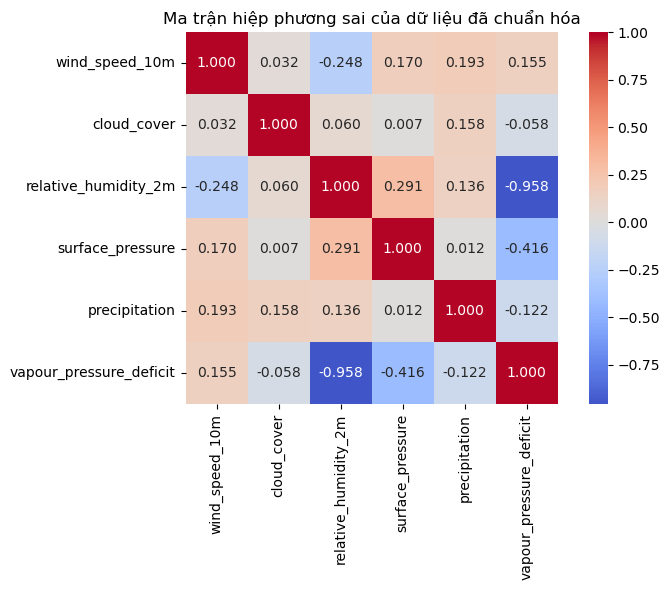

In [15]:
# Tính ma trận hiệp phương sai theo công thức trong slide
# S = (1/N) * X^T * X  (với X đã được chuẩn hóa và trừ mean)
cov_matrix = np.cov(X_train_scaled.T)

# Hiển thị dạng DataFrame cho dễ đọc
cov_df = pd.DataFrame(cov_matrix, 
                       index=feature_cols, 
                       columns=feature_cols)

print("=== MA TRẬN HIỆP PHƯƠNG SAI ===")
print(cov_df.round(3))

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cov_df,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)
ax.set_title('Ma trận hiệp phương sai của dữ liệu đã chuẩn hóa')
plt.tight_layout()
plt.show()

#### Nhận xét:
- relative_humidity_2m ↔ vapour_pressure_deficit = -0.958 — tương quan cực cao → PCA sẽ gộp 2 biến này vào 1 PC
- surface_pressure ↔ vapour_pressure_deficit = -0.416 — tương quan vừa
- Các biến còn lại tương quan thấp với nhau

### Phân tích giá trị riêng (Explained Variance)

=== PHÂN TÍCH GIÁ TRỊ RIÊNG ===

PC       Giá trị riêng  Explained Var (%)  Tích lũy (%)
-------------------------------------------------------
PC1             2.2287             37.14%        37.14%
PC2             1.2959             21.60%        58.74%
PC3             1.0695             17.82%        76.57%
PC4             0.8489             14.15%        90.71%
PC5             0.5271              8.78%        99.50%
PC6             0.0302              0.50%       100.00%


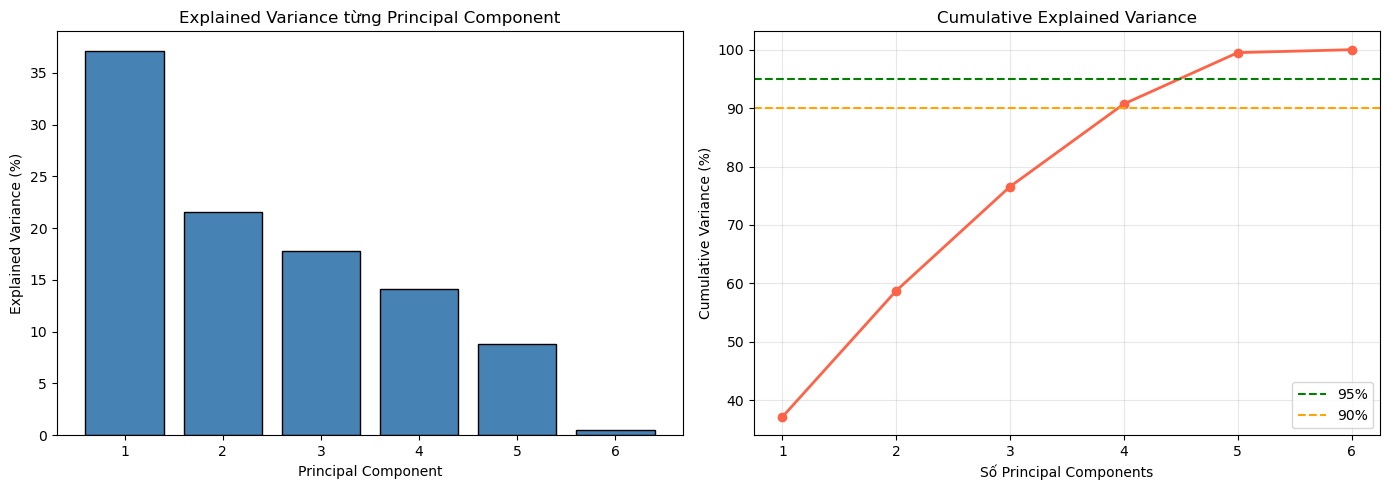

In [16]:
from sklearn.decomposition import PCA

# Chạy PCA với tất cả components
pca = PCA()
pca.fit(X_train_scaled)

# Giá trị riêng và explained variance
eigenvalues = pca.explained_variance_
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("=== PHÂN TÍCH GIÁ TRỊ RIÊNG ===")
print(f"\n{'PC':<6} {'Giá trị riêng':>15} {'Explained Var (%)':>18} {'Tích lũy (%)':>13}")
print("-" * 55)
for i, (ev, exp, cum) in enumerate(zip(eigenvalues, explained_var, cumulative_var)):
    print(f"PC{i+1:<4} {ev:>15.4f} {exp*100:>17.2f}% {cum*100:>12.2f}%")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Explained variance từng PC
axes[0].bar(range(1, len(explained_var)+1), explained_var*100,
            color='steelblue', edgecolor='black')
axes[0].set_title('Explained Variance từng Principal Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xticks(range(1, len(explained_var)+1))

# Biểu đồ 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100,
             marker='o', color='tomato', linewidth=2)
axes[1].axhline(y=95, color='green', linestyle='--', label='95%')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Số Principal Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xticks(range(1, len(cumulative_var)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Nhận xét phần Phân tích giá trị riêng (Explained Variance)
- PC1 giải thích 37.14% phương sai — thành phần quan trọng nhất, chủ yếu đại diện cho nhóm biến ẩm nhiệt (relative_humidity_2m, vapour_pressure_deficit)
- PC1 + PC2 tích lũy 58.74% — chưa đủ để đại diện dữ liệu
- PC1 → PC4 tích lũy 90.71% → vượt ngưỡng 90% → chọn K = 4 là hợp lý nếu muốn giữ ≥ 90% thông tin
- PC1 → PC5 tích lũy 99.50% → vượt ngưỡng 95% → chọn K = 5 nếu muốn giữ tối đa thông tin
- PC6 chỉ đóng góp 0.50% → có thể loại bỏ hoàn toàn

Quyết định: Chọn K = 5

### Phân tích Loading Matrix (đóng góp của từng biến)

=== LOADING MATRIX ===
                           PC1    PC2    PC3    PC4    PC5    PC6
wind_speed_10m           0.140  0.677 -0.405  0.003  0.597  0.052
cloud_cover             -0.076  0.359  0.623  0.690  0.030  0.001
relative_humidity_2m    -0.639 -0.109  0.095 -0.112  0.279  0.694
surface_pressure        -0.355  0.256 -0.561  0.361 -0.597  0.089
precipitation           -0.126  0.578  0.351 -0.616 -0.383 -0.019
vapour_pressure_deficit  0.652  0.040  0.016  0.047 -0.250  0.713


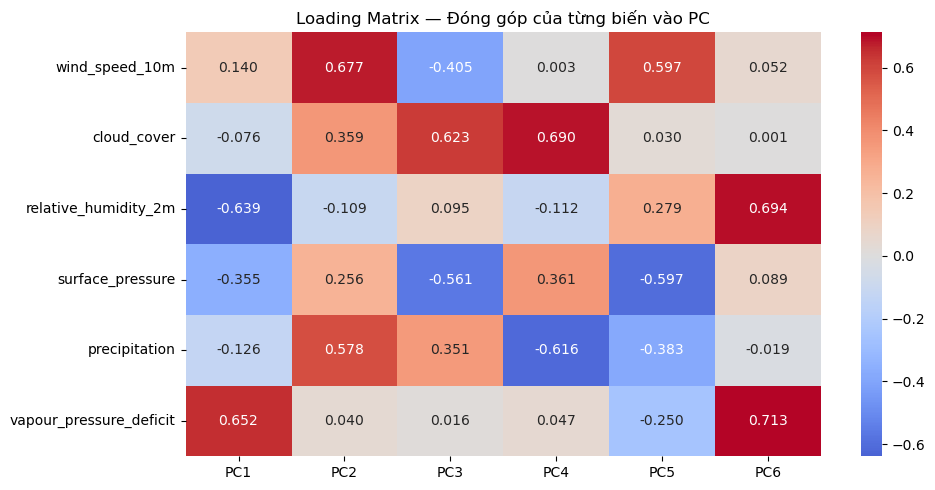


=== Ý NGHĨA TỪNG PC ===
PC1 (37.14%): chủ yếu bởi vapour_pressure_deficit (0.652) và relative_humidity_2m (-0.639)
PC2 (21.60%): chủ yếu bởi wind_speed_10m (0.677) và precipitation (0.578)
PC3 (17.82%): chủ yếu bởi cloud_cover (0.623) và surface_pressure (-0.561)
PC4 (14.15%): chủ yếu bởi cloud_cover (0.690) và precipitation (-0.616)
PC5 (8.78%): chủ yếu bởi wind_speed_10m (0.597) và surface_pressure (-0.597)


In [17]:
# Loading matrix - mức đóng góp của từng biến vào từng PC
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_cols))],
    index=feature_cols
)

print("=== LOADING MATRIX ===")
print(loadings.round(3))

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(loadings,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            center=0,
            ax=ax)
ax.set_title('Loading Matrix — Đóng góp của từng biến vào PC')
plt.tight_layout()
plt.show()

# Nhận xét từng PC
print("\n=== Ý NGHĨA TỪNG PC ===")
for i in range(5):
    pc = loadings[f'PC{i+1}']
    top = pc.abs().nlargest(2).index.tolist()
    print(f"PC{i+1} ({explained_var[i]*100:.2f}%): chủ yếu bởi {top[0]} ({pc[top[0]]:.3f}) và {top[1]} ({pc[top[1]]:.3f})")

### Lựa chọn số chiều K và Transform dữ liệu

In [20]:
# Chọn K=5 giữ 99.50% variance
n_components = 5

pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(f"=== KẾT QUẢ PCA VỚI K={n_components} ===")
print(f"Tổng phương sai giữ lại: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nSố chiều ban đầu : {X_train_scaled.shape[1]}")
print(f"Số chiều sau PCA : {X_train_pca.shape[1]}")
print(f"\nX_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

# Tạo DataFrame
pca_cols = [f'PC{i+1}' for i in range(n_components)]

train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols)
train_pca_df.insert(0, 'time', train_df['time'].values)
train_pca_df['temperature_2m'] = train_df['temperature_2m'].values

test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols)
test_pca_df.insert(0, 'time', test_df['time'].values)
test_pca_df['temperature_2m'] = test_df['temperature_2m'].values

print("\nTrain PCA DataFrame:")
print(train_pca_df.head(3))
print("\nTest PCA DataFrame:")
print(test_pca_df.head(3))

=== KẾT QUẢ PCA VỚI K=5 ===
Tổng phương sai giữ lại: 99.50%

Số chiều ban đầu : 6
Số chiều sau PCA : 5

X_train_pca shape: (42573, 5)
X_test_pca shape: (4731, 5)

Train PCA DataFrame:
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2021-01-01 00:00:00  0.121324  2.398272 -1.870897  1.529343  0.077376   
1 2021-01-01 01:00:00  0.270790  2.193988 -1.713070  1.518056 -0.112719   
2 2021-01-01 02:00:00  0.421603  2.101757 -1.631623  1.467929 -0.142518   

   temperature_2m  
0           19.50  
1           19.50  
2           19.35  

Test PCA DataFrame:
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2025-11-09 21:00:00 -0.990923 -0.419772  0.598336  0.653670 -0.155739   
1 2025-11-09 22:00:00 -1.141169 -0.600791  0.714526  0.629883 -0.234913   
2 2025-11-09 23:00:00 -1.465684 -0.870463  0.865803  0.511503 -0.207914   

   temperature_2m  
0           26.25  
1           26.00  
2           25.35  


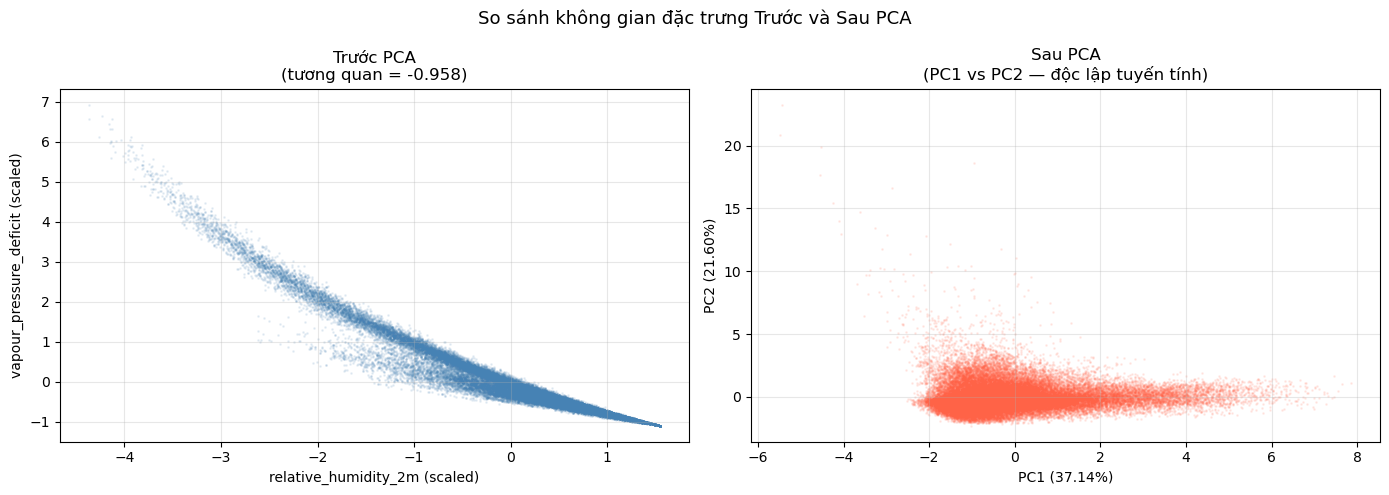

=== SO SÁNH TRƯỚC VÀ SAU PCA ===
Trước PCA: 6 chiều
Sau PCA:   5 chiều
Variance giữ lại: 99.50%
Variance mất đi:  0.50%


In [21]:
# So sánh dữ liệu TRƯỚC và SAU khi PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TRƯỚC PCA — scatter plot 2 biến có tương quan cao nhất
axes[0].scatter(X_train_scaled[:, 2], X_train_scaled[:, 5], 
                alpha=0.1, s=1, color='steelblue')
axes[0].set_xlabel('relative_humidity_2m (scaled)')
axes[0].set_ylabel('vapour_pressure_deficit (scaled)')
axes[0].set_title('Trước PCA\n(tương quan = -0.958)')
axes[0].grid(True, alpha=0.3)

# SAU PCA — scatter plot PC1 vs PC2
axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                alpha=0.1, s=1, color='tomato')
axes[1].set_xlabel('PC1 (37.14%)')
axes[1].set_ylabel('PC2 (21.60%)')
axes[1].set_title('Sau PCA\n(PC1 vs PC2 — độc lập tuyến tính)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh không gian đặc trưng Trước và Sau PCA', fontsize=13)
plt.tight_layout()
plt.show()

# Thêm bảng so sánh số chiều
print("=== SO SÁNH TRƯỚC VÀ SAU PCA ===")
print(f"Trước PCA: {X_train_scaled.shape[1]} chiều")
print(f"Sau PCA:   {X_train_pca.shape[1]} chiều")
print(f"Variance giữ lại: {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Variance mất đi:  {(1-pca_final.explained_variance_ratio_.sum())*100:.2f}%")

## Tạo đặc trưng thời gian (Time Encoding)

### Encoding sin/cos cho giờ trong ngày

=== TIME ENCODING: GIỜ TRONG NGÀY ===
                  time  hour      sin_hour      cos_hour
0  2021-01-01 00:00:00     0  0.000000e+00  1.000000e+00
1  2021-01-01 01:00:00     1  2.588190e-01  9.659258e-01
2  2021-01-01 02:00:00     2  5.000000e-01  8.660254e-01
3  2021-01-01 03:00:00     3  7.071068e-01  7.071068e-01
4  2021-01-01 04:00:00     4  8.660254e-01  5.000000e-01
5  2021-01-01 05:00:00     5  9.659258e-01  2.588190e-01
6  2021-01-01 06:00:00     6  1.000000e+00  6.123234e-17
7  2021-01-01 07:00:00     7  9.659258e-01 -2.588190e-01
8  2021-01-01 08:00:00     8  8.660254e-01 -5.000000e-01
9  2021-01-01 09:00:00     9  7.071068e-01 -7.071068e-01
10 2021-01-01 10:00:00    10  5.000000e-01 -8.660254e-01
11 2021-01-01 11:00:00    11  2.588190e-01 -9.659258e-01
12 2021-01-01 12:00:00    12  1.224647e-16 -1.000000e+00
13 2021-01-01 13:00:00    13 -2.588190e-01 -9.659258e-01
14 2021-01-01 14:00:00    14 -5.000000e-01 -8.660254e-01
15 2021-01-01 15:00:00    15 -7.071068e-01 -7.0710

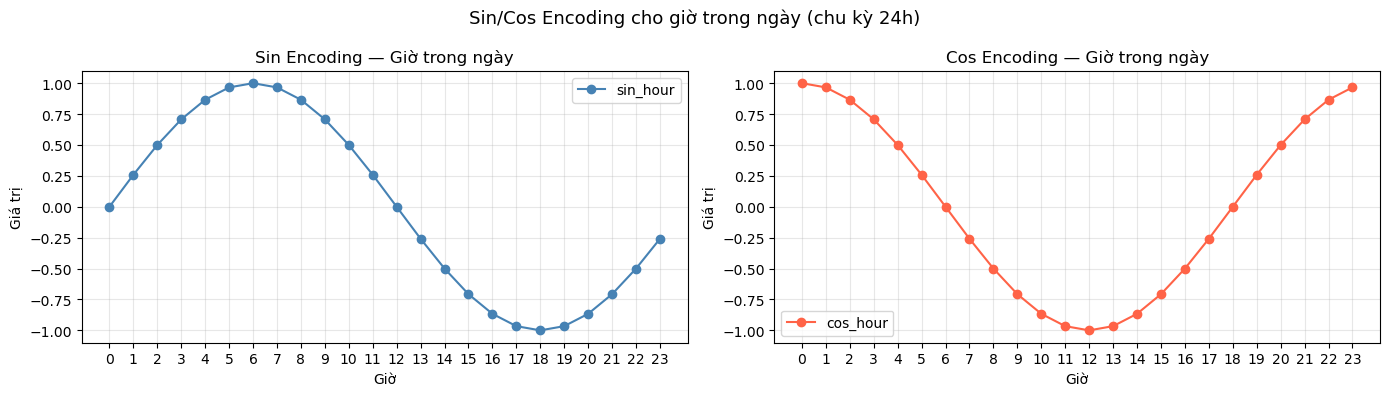

In [ ]:
# Sin/Cos encoding cho giờ trong ngày (chu kỳ 24h)
# Dựa trên kết quả EDA: dữ liệu có chu kỳ ngày rõ ràng

# Tạo trên train
train_df['hour'] = train_df['time'].dt.hour
train_df['sin_hour'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['cos_hour'] = np.cos(2 * np.pi * train_df['hour'] / 24)

# Tạo trên test
test_df['hour'] = test_df['time'].dt.hour
test_df['sin_hour'] = np.sin(2 * np.pi * test_df['hour'] / 24)
test_df['cos_hour'] = np.cos(2 * np.pi * test_df['hour'] / 24)

# Kiểm tra kết quả
print("=== TIME ENCODING: GIỜ TRONG NGÀY ===")
print(train_df[['time', 'hour', 'sin_hour', 'cos_hour']].head(24).to_string())

# Visualize 1 ngày đầu
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hours = train_df['hour'].iloc[:24]
axes[0].plot(hours, train_df['sin_hour'].iloc[:24], 
             marker='o', color='steelblue', label='sin_hour')
axes[0].set_title('Sin Encoding — Giờ trong ngày')
axes[0].set_xlabel('Giờ')
axes[0].set_ylabel('Giá trị')
axes[0].set_xticks(range(24))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hours, train_df['cos_hour'].iloc[:24],
             marker='o', color='tomato', label='cos_hour')
axes[1].set_title('Cos Encoding — Giờ trong ngày')
axes[1].set_xlabel('Giờ')
axes[1].set_ylabel('Giá trị')
axes[1].set_xticks(range(24))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sin/Cos Encoding cho giờ trong ngày (chu kỳ 24h)', fontsize=13)
plt.tight_layout()
plt.show()

#### Nhận xét phần Encoding sin/cos cho giờ trong ngày
- sin_hour và cos_hour đều nằm trong khoảng [-1, 1], tạo thành một vòng tròn đơn vị → đảm bảo tính liên tục tuần hoàn: giờ 23 và giờ 0 gần nhau về mặt toán học
- sin_hour đạt cực đại tại giờ 6 (= 1.0) và cực tiểu tại giờ 18 (= -1.0) → phân biệt sáng/chiều tối
- cos_hour đạt cực đại tại giờ 0 (= 1.0) và cực tiểu tại giờ 12 (= -1.0) → phân biệt nửa đêm/buổi trưa
- Kết hợp sin_hour + cos_hour → mô hình có thể học được vị trí chính xác trong ngày mà không bị discontinuity như khi dùng trực tiếp số nguyên hour

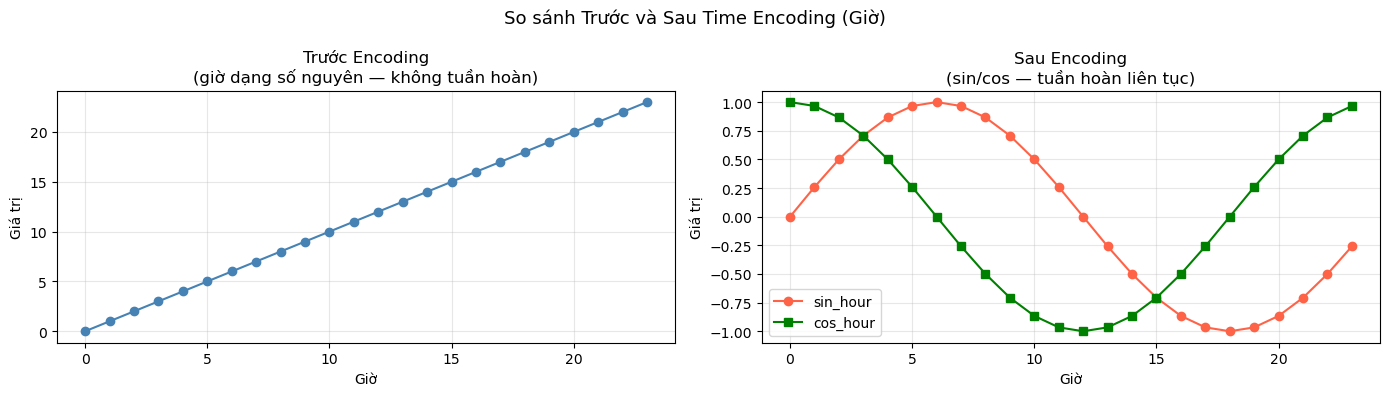

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Trước encoding — giờ dạng số nguyên
axes[0].plot(range(24), range(24), marker='o', color='steelblue')
axes[0].set_title('Trước Encoding\n(giờ dạng số nguyên — không tuần hoàn)')
axes[0].set_xlabel('Giờ')
axes[0].set_ylabel('Giá trị')
axes[0].grid(True, alpha=0.3)

# Sau encoding — sin/cos
hours = range(24)
axes[1].plot(hours, np.sin(2*np.pi*np.array(list(hours))/24), 
             marker='o', color='tomato', label='sin_hour')
axes[1].plot(hours, np.cos(2*np.pi*np.array(list(hours))/24), 
             marker='s', color='green', label='cos_hour')
axes[1].set_title('Sau Encoding\n(sin/cos — tuần hoàn liên tục)')
axes[1].set_xlabel('Giờ')
axes[1].set_ylabel('Giá trị')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau Time Encoding (Giờ)', fontsize=13)
plt.tight_layout()
plt.show()

### Encoding sin/cos cho tháng trong năm

=== TIME ENCODING: THÁNG TRONG NĂM ===
       month     sin_month     cos_month
month                                   
1          1  5.000000e-01  8.660254e-01
2          2  8.660254e-01  5.000000e-01
3          3  1.000000e+00  6.123234e-17
4          4  8.660254e-01 -5.000000e-01
5          5  5.000000e-01 -8.660254e-01
6          6  1.224647e-16 -1.000000e+00
7          7 -5.000000e-01 -8.660254e-01
8          8 -8.660254e-01 -5.000000e-01
9          9 -1.000000e+00 -1.836970e-16
10        10 -8.660254e-01  5.000000e-01
11        11 -5.000000e-01  8.660254e-01
12        12 -2.449294e-16  1.000000e+00


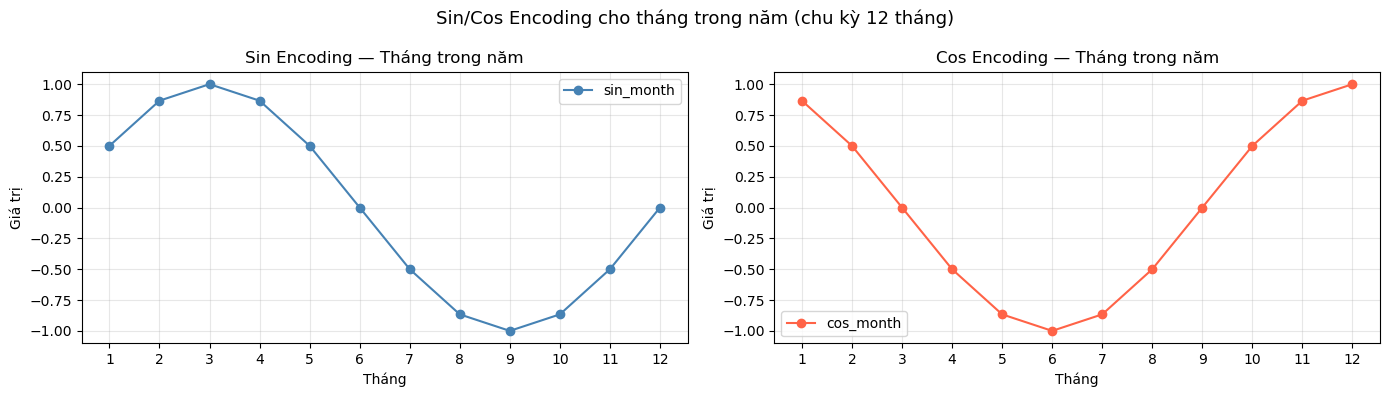

In [ ]:
# Sin/Cos encoding cho tháng trong năm (chu kỳ 12 tháng)
# Dựa trên kết quả EDA: seasonal decompose cho thấy chu kỳ năm rõ ràng

# Tạo trên train
train_df['month'] = train_df['time'].dt.month
train_df['sin_month'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['cos_month'] = np.cos(2 * np.pi * train_df['month'] / 12)

# Tạo trên test
test_df['month'] = test_df['time'].dt.month
test_df['sin_month'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['cos_month'] = np.cos(2 * np.pi * test_df['month'] / 12)

# Kiểm tra kết quả
print("=== TIME ENCODING: THÁNG TRONG NĂM ===")
# In 1 giá trị đại diện mỗi tháng
monthly_sample = train_df.groupby('month')[['month', 'sin_month', 'cos_month']].first()
print(monthly_sample.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

months = range(1, 13)
sin_vals = np.sin(2 * np.pi * np.array(list(months)) / 12)
cos_vals = np.cos(2 * np.pi * np.array(list(months)) / 12)

axes[0].plot(months, sin_vals, marker='o', color='steelblue', label='sin_month')
axes[0].set_title('Sin Encoding — Tháng trong năm')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Giá trị')
axes[0].set_xticks(range(1, 13))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(months, cos_vals, marker='o', color='tomato', label='cos_month')
axes[1].set_title('Cos Encoding — Tháng trong năm')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Giá trị')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sin/Cos Encoding cho tháng trong năm (chu kỳ 12 tháng)', fontsize=13)
plt.tight_layout()
plt.show()

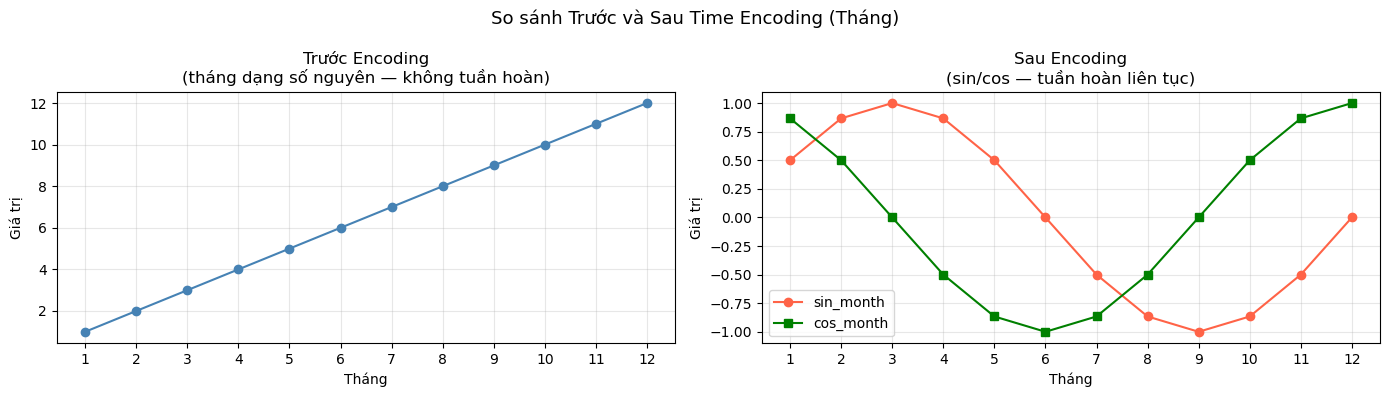

In [ ]:
# So sánh Trước và Sau Time Encoding (Tháng)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Trước encoding — tháng dạng số nguyên
axes[0].plot(range(1, 13), range(1, 13), marker='o', color='steelblue')
axes[0].set_title('Trước Encoding\n(tháng dạng số nguyên — không tuần hoàn)')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Giá trị')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Sau encoding — sin/cos cho tháng
months = range(1, 13)
axes[1].plot(months, np.sin(2*np.pi*np.array(list(months))/12), 
             marker='o', color='tomato', label='sin_month')
axes[1].plot(months, np.cos(2*np.pi*np.array(list(months))/12), 
             marker='s', color='green', label='cos_month')
axes[1].set_title('Sau Encoding\n(sin/cos — tuần hoàn liên tục)')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Giá trị')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau Time Encoding (Tháng)', fontsize=13)
plt.tight_layout()
plt.show()

## Tạo Lag Features

In [ ]:
# Ghép train và test để tạo lag liên tục
train_pca_df['is_train'] = 1
test_pca_df['is_train'] = 0

# Thêm encoding vào pca_df
train_pca_df['sin_hour'] = train_df['sin_hour'].values
train_pca_df['cos_hour'] = train_df['cos_hour'].values
train_pca_df['sin_month'] = train_df['sin_month'].values
train_pca_df['cos_month'] = train_df['cos_month'].values

test_pca_df['sin_hour'] = test_df['sin_hour'].values
test_pca_df['cos_hour'] = test_df['cos_hour'].values
test_pca_df['sin_month'] = test_df['sin_month'].values
test_pca_df['cos_month'] = test_df['cos_month'].values

# Ghép lại
full_df = pd.concat([train_pca_df, test_pca_df], ignore_index=True)
full_df = full_df.sort_values('time').reset_index(drop=True)

# Tạo lag features
lag_hours = [1, 2, 3, 12, 24, 72, 168] # Lags: 1h, 2h, 3h, 12h, 24h, 3 ngày (72h), 7 ngày (168h)
for lag in lag_hours:
    full_df[f'temp_lag_{lag}'] = full_df['temperature_2m'].shift(lag)

# Tách lại train và test
train_final = full_df[full_df['is_train'] == 1].dropna().reset_index(drop=True)
test_final = full_df[full_df['is_train'] == 0].dropna().reset_index(drop=True)

# Bỏ cột is_train
train_final = train_final.drop(columns=['is_train'])
test_final = test_final.drop(columns=['is_train'])

print("=== KẾT QUẢ LAG FEATURES ===")
print(f"\nTrain shape: {train_final.shape}")
print(f"Test shape: {test_final.shape}")
print(f"\nCác cột lag: {[col for col in train_final.columns if 'lag' in col]}")
print(f"\nTất cả cột: {train_final.columns.tolist()}")
print(f"\nTrain time range: {train_final['time'].min()} → {train_final['time'].max()}")
print(f"Test time range:  {test_final['time'].min()} → {test_final['time'].max()}")
print("\nTrain head:")
print(train_final.head(3))

=== KẾT QUẢ LAG FEATURES ===

Train shape: (42405, 18)
Test shape: (4731, 18)

Các cột lag: ['temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_12', 'temp_lag_24', 'temp_lag_72', 'temp_lag_168']

Tất cả cột: ['time', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'temperature_2m', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_12', 'temp_lag_24', 'temp_lag_72', 'temp_lag_168']

Train time range: 2021-01-08 00:00:00 → 2025-11-09 20:00:00
Test time range:  2025-11-09 21:00:00 → 2026-05-25 23:00:00

Train head:
                 time       PC1       PC2       PC3       PC4       PC5  \
0 2021-01-08 00:00:00 -1.323048  0.419816 -0.073624  0.794602 -0.336020   
1 2021-01-08 01:00:00 -1.362823  0.653598 -0.126276  0.706323 -0.116376   
2 2021-01-08 02:00:00 -1.636249  1.015001  0.325073  0.095126 -0.464291   

   temperature_2m  sin_hour  cos_hour  sin_month  cos_month  temp_lag_1  \
0           21.20  0.000000  1.000000        0.5   0.866025       

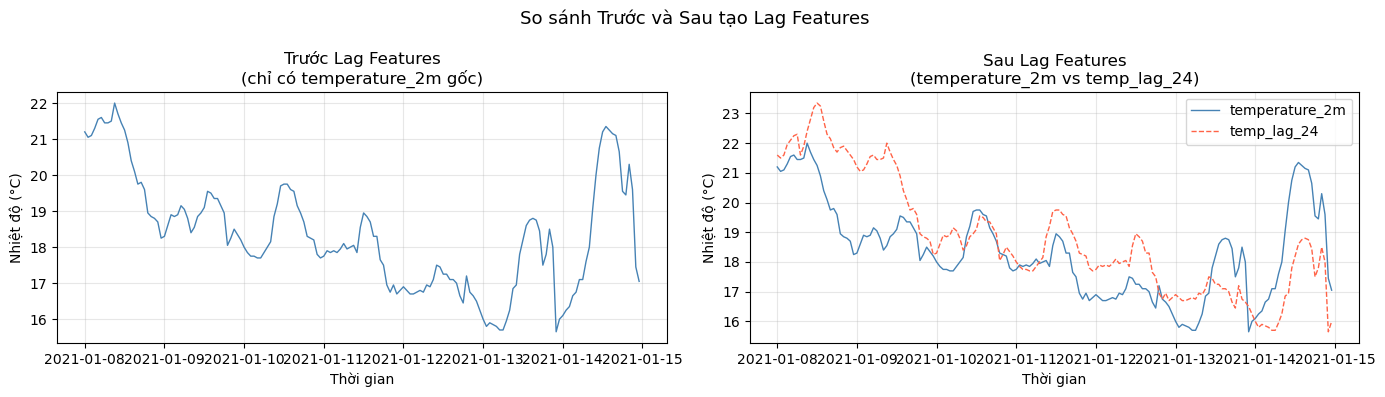

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Trước lag — chỉ có temperature_2m gốc
axes[0].plot(train_final['time'].iloc[:168], 
             train_final['temperature_2m'].iloc[:168],
             color='steelblue', linewidth=1)
axes[0].set_title('Trước Lag Features\n(chỉ có temperature_2m gốc)')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('Nhiệt độ (°C)')
axes[0].grid(True, alpha=0.3)

# Sau lag — so sánh temp và lag_24
axes[1].plot(train_final['time'].iloc[:168], 
             train_final['temperature_2m'].iloc[:168],
             color='steelblue', linewidth=1, label='temperature_2m')
axes[1].plot(train_final['time'].iloc[:168], 
             train_final['temp_lag_24'].iloc[:168],
             color='tomato', linewidth=1, linestyle='--', label='temp_lag_24')
axes[1].set_title('Sau Lag Features\n(temperature_2m vs temp_lag_24)')
axes[1].set_xlabel('Thời gian')
axes[1].set_ylabel('Nhiệt độ (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh Trước và Sau tạo Lag Features', fontsize=13)
plt.tight_layout()
plt.show()

# 3. Training

In [ ]:
print("="*50)
print("BƯỚC 4: TÁCH BIẾN NGOẠI SINH (FEATURES) VÀ BIẾN MỤC TIÊU (TARGET)")
print("="*50)

# Định nghĩa danh sách các đặc trưng (bao gồm biến trễ và biến ngoại sinh)
# Nếu dữ liệu của bạn có thêm cột 'relative_humidity_2m (%)' hoặc 'rain', hãy thêm vào list này nhé!
feature_cols = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'day_of_year',
    'lag_1', 'lag_2', 'lag_3', 'lag_24',
    'rolling_mean_24', 'rolling_std_24'
]

target_col = 'temperature_2m (°C)'

# Tách thành ma trận X và mảng y
X_train = train_df[feature_cols]
y_train = train_df[target_col]

print(f"✅ Đã cấu hình xong không gian đặc trưng (Feature Space):")
print(f" - Số lượng biến ngoại sinh và biến trễ đầu vào (X): {len(feature_cols)} biến.")
print(f" - Biến mục tiêu cần dự báo (y): '{target_col}'")
print(f" - Kích thước X_train: {X_train.shape}")
print(f" - Kích thước y_train: {y_train.shape}")

In [ ]:
import xgboost as xgb
import pickle
import os

print("="*50)
print("BƯỚC 5: HUẤN LUYỆN MÔ HÌNH XGBOOST REGRESSOR")
print("="*50)

# 1. KHỞI TẠO MÔ HÌNH XGBOOST
# Cấu hình các tham số để kiểm soát overfitting và tối ưu cho chuỗi thời gian
model = xgb.XGBRegressor(
    n_estimators=100,      # Số lượng cây quyết định
    max_depth=6,           # Độ sâu tối đa của cây
    learning_rate=0.1,     # Tốc độ học
    subsample=0.8,         # Tỷ lệ lấy mẫu dòng cho mỗi cây (chống overfitting)
    colsample_bytree=0.8,  # Tỷ lệ lấy mẫu cột (biến ngoại sinh) cho mỗi cây
    random_state=42,
    n_jobs=-1              # Sử dụng tối đa hiệu năng CPU để train nhanh
)

# 2. TIẾN HÀNH HUẤN LUYỆN (FIT MODEL)
print("-> Đang huấn luyện mô hình XGBoost với các biến ngoại sinh...")
model.fit(X_train, y_train)
print("✅ Huấn luyện mô hình thành công!")

# 3. ĐÓNG GÓI VÀ LƯU TRỮ MÔ HÌNH (ĐỂ DÙNG BÊN FILE TESTING.IPYNB)
# Tạo thư mục lưu trữ nếu chưa có
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Lưu model XGBoost
model_path = os.path.join(model_dir, "xgboost_weather_model.pkl")
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# Lưu kèm danh sách cột thuộc tính để bên test_df trích xuất khớp 100%
features_path = os.path.join(model_dir, "feature_columns.pkl")
with open(features_path, 'wb') as f:
    pickle.dump(feature_cols, f)

print(f"\n📦 Đã đóng gói và lưu trữ thành công:")
print(f" - File mô hình: {model_path}")
print(f" - File danh sách đặc trưng: {features_path}")